In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/processed/merged_dataset.parquet")

df["close_approach_date"] = pd.to_datetime(
    df["close_approach_date"]
)

df["year"] = df["close_approach_date"].dt.year

In [2]:
yearly_counts = (
    df.groupby("year")
      .size()
      .reset_index(name="neo_count")
)

yearly_counts

,year,neo_count
0,2015,1127
1,2016,1419
2,2017,1569
3,2018,1656
4,2019,1938
5,2020,2336
6,2021,2501
7,2022,2607
8,2023,2521
9,2024,2504


In [3]:
train = yearly_counts[
    yearly_counts["year"] <= 2025
]

test = yearly_counts[
    yearly_counts["year"] > 2025
]

In [4]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train["neo_count"],
    order=(2,1,2)
)

model_fit = model.fit()

C:\Users\SATYAM\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\SATYAM\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [6]:
results = pd.DataFrame({
    "year": test["year"].values,
    "actual": test["neo_count"].values,
    "forecast": forecast.values
})

results

,year,actual,forecast
0,2026,1039,2762.212326
1,2027,435,2908.816815
2,2028,443,3042.966494
3,2029,395,3180.439480
4,2030,406,3316.932235
5,2031,367,3453.618604
6,2032,384,3590.178444
7,2033,374,3726.699109
8,2034,378,3863.156803
9,2035,362,3999.558047


In [7]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    results["actual"],
    results["forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        results["actual"],
        results["forecast"]
    )
)

r2 = r2_score(
    results["actual"],
    results["forecast"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2926.1578357182393
RMSE: 2975.0090440903596
R2  : -231.04785567309386


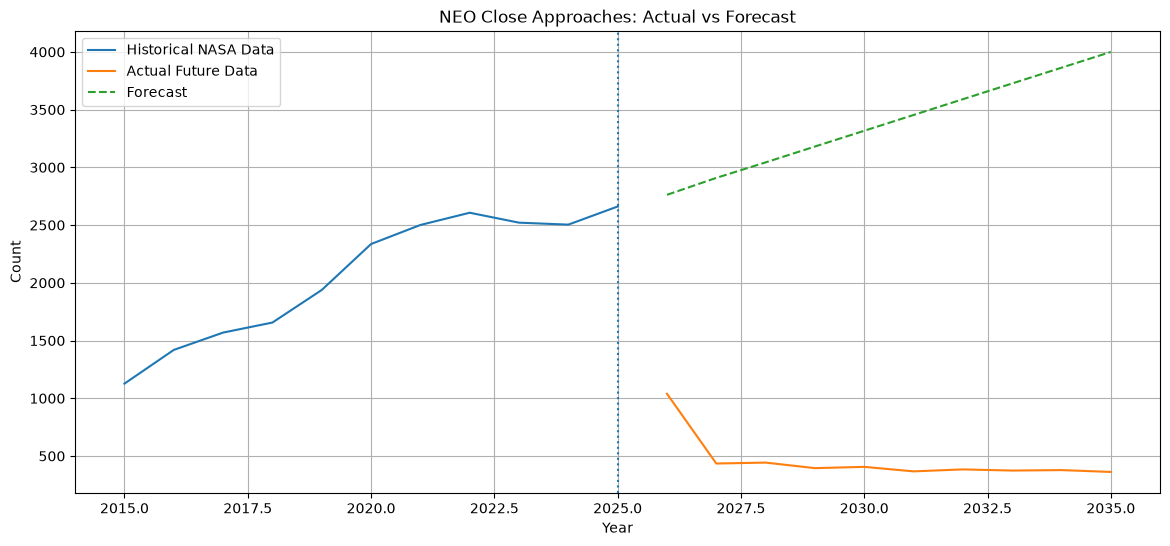

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    train["year"],
    train["neo_count"],
    label="Historical NASA Data"
)

plt.plot(
    results["year"],
    results["actual"],
    label="Actual Future Data"
)

plt.plot(
    results["year"],
    results["forecast"],
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    2025,
    linestyle=":"
)

plt.title(
    "NEO Close Approaches: Actual vs Forecast"
)

plt.xlabel("Year")
plt.ylabel("Count")

plt.legend()

plt.grid(True)

plt.show()

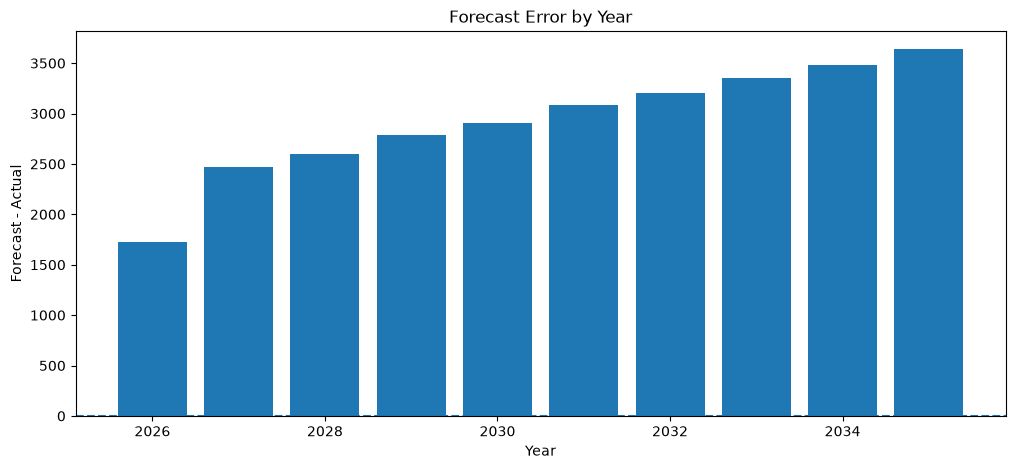

In [9]:
results["error"] = (
    results["forecast"]
    -
    results["actual"]
)

plt.figure(figsize=(12,5))

plt.bar(
    results["year"],
    results["error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Forecast Error by Year"
)

plt.xlabel("Year")
plt.ylabel("Forecast - Actual")

plt.show()

In [10]:
results.to_csv(
    "../data/exports/forecast_validation.csv",
    index=False
)

In [11]:
results.to_json(
    "../data/exports/forecast_validation.json",
    orient="records"
)